In [4]:
import zipfile
import os

arquivo_zip = 'archive.zip'

if os.path.exists(arquivo_zip):
    with zipfile.ZipFile(arquivo_zip, 'r') as zip_ref:
        zip_ref.extractall()
        print("Os arquivos foram extraídos")
else:
    print(f"Erro: O arquivo {arquivo_zip} não foi encontrado na pasta lateral.")

Os arquivos foram extraídos


In [5]:
import pandas as pd
import sqlite3

# Lendo os arquivos extraídos
pedidos = pd.read_csv('olist_orders_dataset.csv')
pagamentos = pd.read_csv('olist_order_payments_dataset.csv')
itens = pd.read_csv('olist_order_items_dataset.csv')

# Conectando ao banco (cria o arquivo olist_database.db)
conn = sqlite3.connect('olist_database.db')

# Enviando para o SQL
pedidos.to_sql('pedidos', conn, if_exists='replace', index=False)
pagamentos.to_sql('pagamentos', conn, if_exists='replace', index=False)
itens.to_sql('itens', conn, if_exists='replace', index=False)

print("Tabelas SQL criadas foram criadas.")

Tabelas SQL criadas foram criadas.


In [6]:
query_formatada = """
SELECT
    order_status,
    ROUND(SUM(payment_value), 2) AS receita_total
FROM pedidos
JOIN pagamentos ON pedidos.order_id = pagamentos.order_id
GROUP BY order_status
ORDER BY receita_total DESC
"""

df_formatado = pd.read_sql(query_formatada, conn)
df_formatado

,order_status,receita_total
0,delivered,15422461.77
1,shipped,177213.96
2,canceled,143255.60
3,unavailable,126479.51
4,processing,69394.11
5,invoiced,69137.99
6,created,688.10
7,approved,241.08


In [7]:
query_limpeza = """
CREATE VIEW IF NOT EXISTS v_vendas_limpas AS
SELECT
    order_id,
    customer_id,
    CASE
        WHEN order_status = 'delivered' THEN 'Entregue'
        WHEN order_status = 'canceled' THEN 'Cancelado'
        WHEN order_status = 'shipped' THEN 'Enviado'
        ELSE 'Outros'
    END AS status_pt,
    datetime(order_purchase_timestamp) AS data_compra
FROM pedidos;
"""
conn.execute(query_limpeza)
print("Camada de limpeza criada.")

Camada de limpeza criada.


In [8]:
# Carregando o arquivo
df_produtos = pd.read_csv('olist_products_dataset.csv')

# Enviando para o banco SQL
df_produtos.to_sql('produtos', conn, if_exists='replace', index=False)

print("Tabela 'produtos' carregada.")

query_fato = """
SELECT
    p.product_category_name AS categoria,
    COUNT(i.order_id) AS qtd_vendas,
    ROUND(SUM(pay.payment_value), 2) AS receita_total
FROM itens i
JOIN pedidos ped ON i.order_id = ped.order_id
JOIN pagamentos pay ON i.order_id = pay.order_id
JOIN produtos p ON i.product_id = p.product_id
GROUP BY categoria
ORDER BY receita_total DESC
LIMIT 10;
"""
df_categorias = pd.read_sql(query_fato, conn)
df_categorias

Tabela 'produtos' carregada.


,categoria,qtd_vendas,receita_total
0,cama_mesa_banho,11823,1712553.67
1,beleza_saude,9972,1657373.12
2,informatica_acessorios,8082,1585330.45
3,moveis_decoracao,8744,1430176.39
4,relogios_presentes,6201,1429216.68
5,esporte_lazer,8945,1392127.56
6,utilidades_domesticas,7355,1094758.13
7,automotivo,4379,852294.33
8,ferramentas_jardim,4574,838280.75
9,cool_stuff,3987,779698.00


In [15]:
query_pareto = """
WITH ReceitaPorCategoria AS (
    SELECT
        p.product_category_name AS categoria,
        SUM(pay.payment_value) AS receita
    FROM itens i
    JOIN pagamentos pay ON i.order_id = pay.order_id
    JOIN produtos p ON i.product_id = p.product_id
    GROUP BY 1
),
CalculoPercentual AS (
    SELECT
        categoria,
        receita,
        SUM(receita) OVER (ORDER BY receita DESC) / SUM(receita) OVER () AS perc_acumulado
    FROM ReceitaPorCategoria
)
SELECT
    categoria,
    ROUND(receita, 2) AS receita,
    ROUND(perc_acumulado * 100, 2) AS percentual_acumulado_vendas,
    CASE
        WHEN perc_acumulado <= 0.8 THEN 'A (Foco Total)'
        WHEN perc_acumulado <= 0.95 THEN 'B (Intermediário)'
        ELSE 'C (Cauda Longa)'
    END AS classificacao_abc
FROM CalculoPercentual;
"""

df_abc = pd.read_sql(query_pareto, conn)
df_abc.head(15) # Ver as 15 principais

,categoria,receita,percentual_acumulado_vendas,classificacao_abc
0,cama_mesa_banho,1712553.67,8.43,A (Foco Total)
1,beleza_saude,1657373.12,16.59,A (Foco Total)
2,informatica_acessorios,1585330.45,24.40,A (Foco Total)
3,moveis_decoracao,1430176.39,31.44,A (Foco Total)
4,relogios_presentes,1429216.68,38.48,A (Foco Total)
5,esporte_lazer,1392127.56,45.34,A (Foco Total)
6,utilidades_domesticas,1094758.13,50.73,A (Foco Total)
7,automotivo,852294.33,54.92,A (Foco Total)
8,ferramentas_jardim,838280.75,59.05,A (Foco Total)
9,cool_stuff,779698.00,62.89,A (Foco Total)


/tmp/ipykernel_47375/3988257392.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


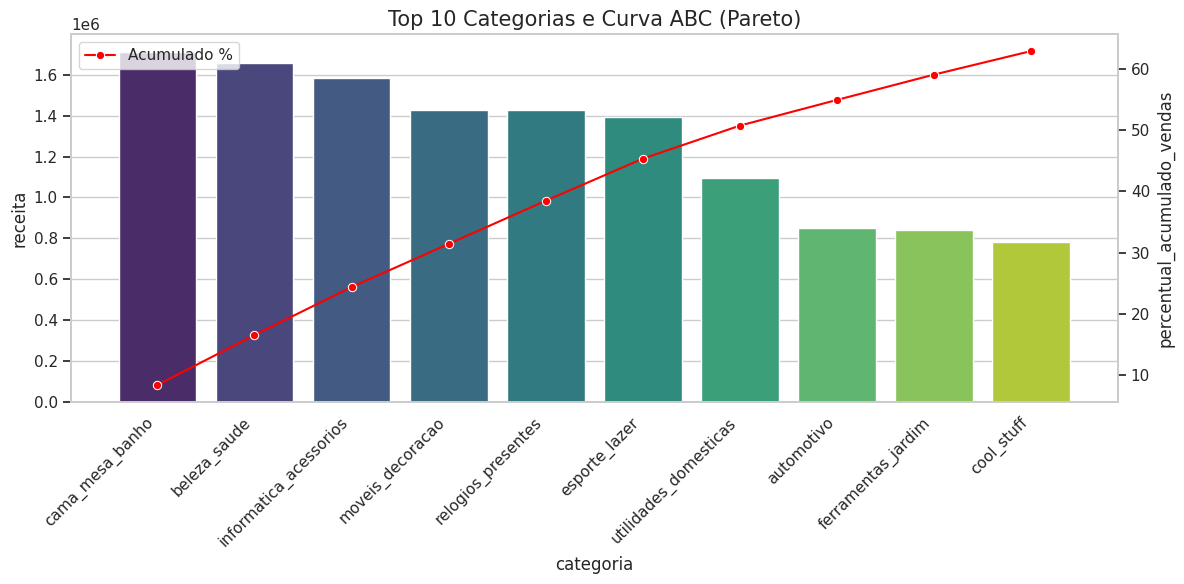

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configurando o estilo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# 2. Criando o gráfico de barras (Adicionado o 'hue' e 'legend=False')
ax = sns.barplot(
    data=df_abc.head(10),
    x='categoria',
    y='receita',
    hue='categoria', # Define a cor baseada na categoria
    palette='viridis',
    legend=False     # Remove a legenda automática que o hue criaria
)

# 3. Adicionando a linha do percentual acumulado (Eixo secundário)
ax2 = ax.twinx()
sns.lineplot(
    data=df_abc.head(10),
    x='categoria',
    y='percentual_acumulado_vendas',
    marker='o',
    color='red',
    ax=ax2,
    label='Acumulado %'
)

# 4. Ajustes finos de layout
ax.set_title('Top 10 Categorias e Curva ABC (Pareto)', fontsize=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Garante que as legendas não fiquem em cima do gráfico
ax2.grid(False) # Remove o grid do eixo secundário para não poluir
plt.tight_layout()
plt.show()

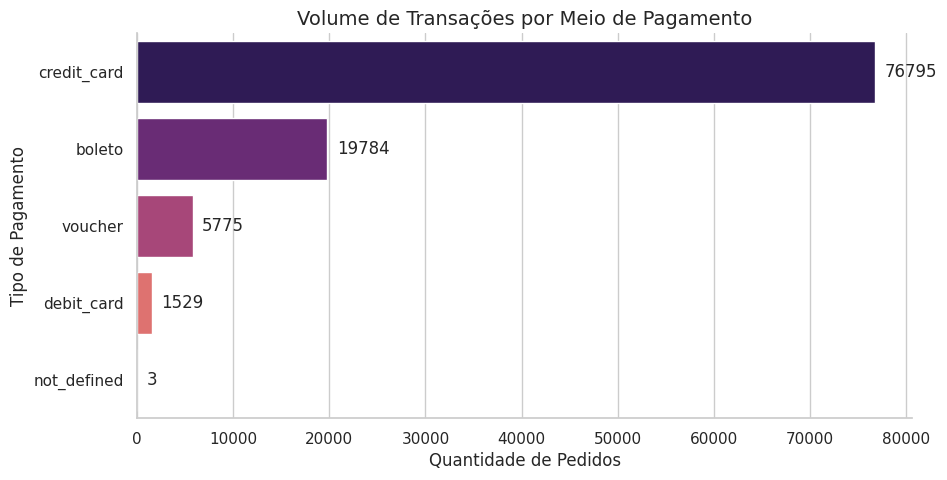

In [17]:
# 1. Buscar os dados do banco (Garante que a variável df_pay_dist exista)
query_pagamentos = "SELECT payment_type, COUNT(*) as total FROM pagamentos GROUP BY 1"
df_pay_dist = pd.read_sql(query_pagamentos, conn)

# 2. Configurar e criar o gráfico de barras
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=df_pay_dist.sort_values('total', ascending=False),
    x='total',
    y='payment_type',
    hue='payment_type',
    palette='magma',
    legend=False
)

# Adicionando os valores exatos na frente das barras
for p in ax.patches:
    width = p.get_width()
    ax.text(width + 1000, p.get_y() + p.get_height()/2,
            f'{int(width)}', ha='left', va='center')

plt.title('Volume de Transações por Meio de Pagamento', fontsize=14)
plt.xlabel('Quantidade de Pedidos')
plt.ylabel('Tipo de Pagamento')
sns.despine()
plt.show()

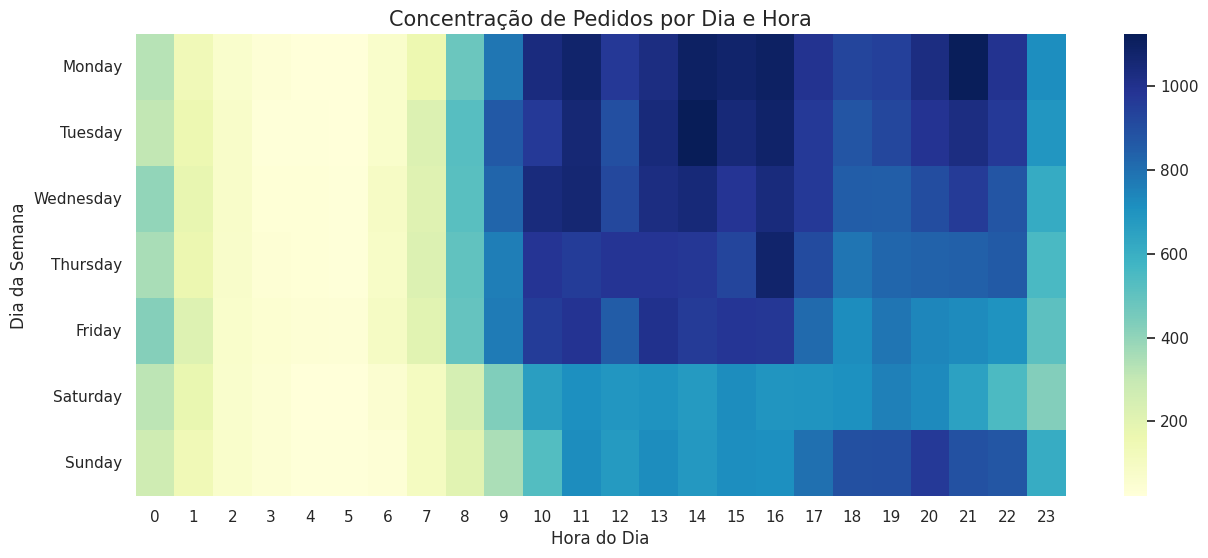

In [21]:
# Preparando os dados
pedidos['order_purchase_timestamp'] = pd.to_datetime(pedidos['order_purchase_timestamp'])
pedidos['dia_semana'] = pedidos['order_purchase_timestamp'].dt.day_name()
pedidos['hora'] = pedidos['order_purchase_timestamp'].dt.hour

# Criando a matriz para o Heatmap
heatmap_data = pedidos.groupby(['dia_semana', 'hora']).size().unstack()

# Ordenando os dias da semana corretamente
dias_ordem = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = heatmap_data.reindex(dias_ordem)

plt.figure(figsize=(15, 6))
sns.heatmap(heatmap_data, cmap='YlGnBu', annot=False)
plt.title('Concentração de Pedidos por Dia e Hora', fontsize=15)
plt.xlabel('Hora do Dia')
plt.ylabel('Dia da Semana')
plt.show()

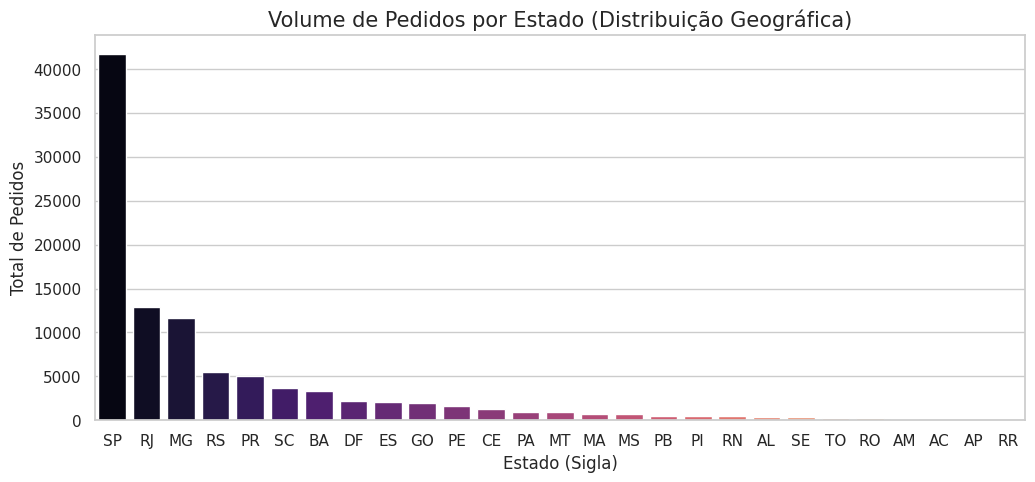

In [18]:
# 1. Carregando a tabela de clientes e salvando no banco
df_clientes = pd.read_csv('olist_customers_dataset.csv')
df_clientes.to_sql('clientes', conn, if_exists='replace', index=False)

# 2. Consulta SQL: Vendas por Estado
query_geografia = """
SELECT
    customer_state AS estado,
    COUNT(order_id) AS total_pedidos
FROM clientes
JOIN pedidos ON clientes.customer_id = pedidos.customer_id
GROUP BY 1
ORDER BY total_pedidos DESC
"""
df_geo = pd.read_sql(query_geografia, conn)

# 3. Visualização Geográfica
plt.figure(figsize=(12, 5))

# Ajuste: Adicionado 'hue' e 'legend=False'
sns.barplot(
    data=df_geo,
    x='estado',
    y='total_pedidos',
    hue='estado',
    palette='magma',
    legend=False
)

plt.title('Volume de Pedidos por Estado (Distribuição Geográfica)', fontsize=15)
plt.xlabel('Estado (Sigla)')
plt.ylabel('Total de Pedidos')
plt.show()

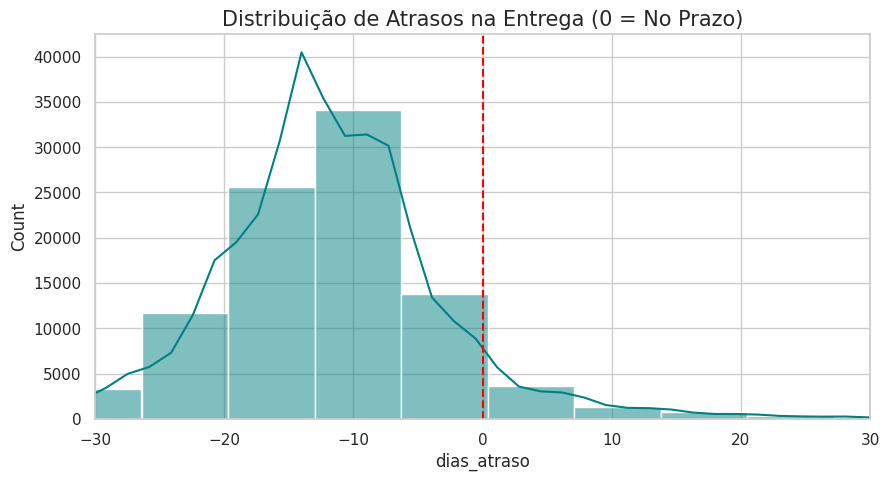

In [23]:
# Convertendo para datetime
pedidos['order_delivered_customer_date'] = pd.to_datetime(pedidos['order_delivered_customer_date'])
pedidos['order_estimated_delivery_date'] = pd.to_datetime(pedidos['order_estimated_delivery_date'])

# Calculando o atraso (em dias)
# Valores negativos significam que chegou ANTES do prazo (ótimo)
pedidos['dias_atraso'] = (pedidos['order_delivered_customer_date'] - pedidos['order_estimated_delivery_date']).dt.days

plt.figure(figsize=(10, 5))
sns.histplot(pedidos['dias_atraso'].dropna(), bins=50, kde=True, color='teal')
plt.axvline(0, color='red', linestyle='--') # Linha do prazo
plt.title('Distribuição de Atrasos na Entrega (0 = No Prazo)', fontsize=15)
plt.xlim(-30, 30) # Focando no intervalo principal
plt.show()

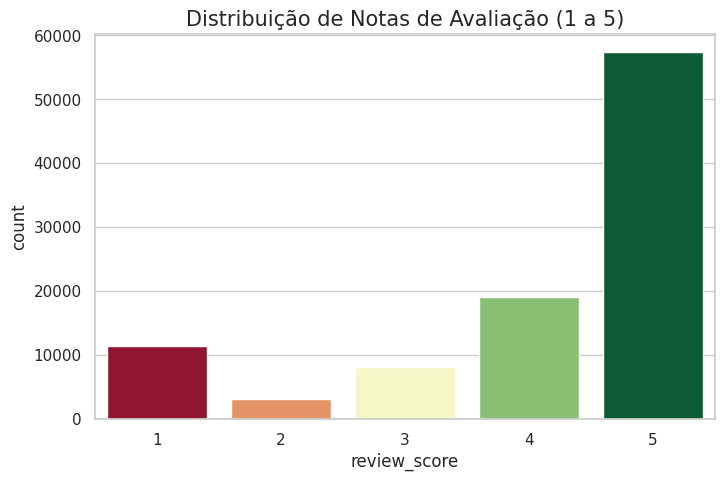

In [26]:
# Carregando a tabela de reviews
df_reviews = pd.read_csv('olist_order_reviews_dataset.csv')
df_reviews.to_sql('reviews', conn, if_exists='replace', index=False)

# Gráfico de contagem de notas
plt.figure(figsize=(8, 5))
sns.countplot(data=df_reviews, x='review_score', hue='review_score', palette='RdYlGn', legend=False)
plt.title('Distribuição de Notas de Avaliação (1 a 5)', fontsize=15)
plt.show()